### Imports and Configuration


In [1]:
# Import shared libraries, metrics, and utilities used throughout the TON_IoT modeling workflow.
# Keep metric imports centralized so split evaluation and cross-validation use consistent definitions.
# Configure warnings once to keep long experimental output readable during repeated reruns.

import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score, roc_auc_score,
                              average_precision_score)
from sklearn.model_selection import StratifiedKFold, cross_validate

### Paths and Data Loading


In [2]:
# Build project-relative paths to keep the notebook portable across environments and machines.
# Load the prepared TON_IoT train/validation/test splits so each model is evaluated on the same partitions.
# Ensure output directories exist before training so artifact persistence does not fail at the end.

from pathlib import Path
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

NOTEBOOK_DIR =  Path('/content/drive/MyDrive/MLmodeling/XAI/notebooks_v1')
BASE_DIR     = Path('/content/drive/MyDrive/MLmodeling/XAI')
DATASET_DIR  = BASE_DIR / 'Datasets' / 'TON_IOT'
SPLITS_DIR   = BASE_DIR / 'splits' / 'TON_IoT'
MODEL_DIR    = BASE_DIR / 'models' / 'TON_IoT'
RESULT_DIR   = BASE_DIR / 'results' / 'TON_IoT'
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(SPLITS_DIR / 'X_train_proc.npy')
X_val   = np.load(SPLITS_DIR / 'X_val_proc.npy')
X_test  = np.load(SPLITS_DIR / 'X_test_proc.npy')

y_train = pd.read_csv(SPLITS_DIR / 'y_train.csv').squeeze()
y_val   = pd.read_csv(SPLITS_DIR / 'y_val.csv').squeeze()
y_test  = pd.read_csv(SPLITS_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Mounted at /content/drive
Train: (147724, 98) | Val: (31662, 98) | Test: (31657, 98)


### Model Definition


In [3]:
# Define IsolationForest with explicit hyperparameters so this experiment remains reproducible and comparable.
# Keep model initialization isolated from training/evaluation so tuning edits stay localized.
# `random_state=42` is set to reduce run-to-run variance and keep benchmark comparisons fair.

from sklearn.ensemble import IsolationForest

ARTIFACT_NAME = "TON_15_IsolationForest"
MODEL_NAME = "IsolationForest"
model = IsolationForest(contamination='auto', random_state=42, n_jobs=-1)


### Train and Evaluate


In [4]:
# Fit the model and evaluate train/validation/test in one flow to expose overfitting or underfitting quickly.
# Report threshold metrics (accuracy, precision, recall, F1, F2) and ranking metrics (ROC-AUC, PR-AUC).
# PR-AUC is especially useful when attack classes are imbalanced, so it complements ROC-AUC here.

# Unsupervised   fit on train features only, no labels
model.fit(X_train)

def predict_binary(model, X):
    # -1 = anomaly = attack (1), +1 = inlier = normal (0)
    return np.where(model.predict(X) == -1, 1, 0)

y_pred_train = predict_binary(model, X_train)
y_pred_val   = predict_binary(model, X_val)
y_pred_test  = predict_binary(model, X_test)

def eval_unsupervised(y_true, y_pred, split_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    f2   = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    print(f"{split_name:6s}   Accuracy: {acc:.4f} | Precision: {prec:.4f} | "
          f"Recall: {rec:.4f} | F1: {f1:.4f} | F2: {f2:.4f}")

eval_unsupervised(y_train, y_pred_train, "Train")
eval_unsupervised(y_val,   y_pred_val,   "Val")
eval_unsupervised(y_test,  y_pred_test,  "Test")

Train    Accuracy: 0.2491 | Precision: 0.5589 | Recall: 0.0754 | F1: 0.1329 | F2: 0.0912
Val      Accuracy: 0.2464 | Precision: 0.5460 | Recall: 0.0737 | F1: 0.1299 | F2: 0.0891
Test     Accuracy: 0.2481 | Precision: 0.5533 | Recall: 0.0763 | F1: 0.1341 | F2: 0.0922


### Model Evaluation (Unsupervised - No cross validation)

In [5]:
# Isolation Forest is an unsupervised learning model.
# It does not use labeled data (y), so techniques like Stratified K-Fold CV
# cannot be applied because they rely on class labels to split data.

# In unsupervised learning:
# - There is no ground truth for validation during training
# - Metrics like F1, ROC require true labels, which are not available
# - Hence, traditional cross-validation is not applicable

# Instead, we evaluate stability using:
# - Train / Validation / Test consistency
# - Distribution of anomaly scores
# - Domain-based validation (if labels available externally)


cv_results = {
    "cv_train_f1_mean": None,
    "cv_val_f1_mean":   None,
    "cv_val_f1_std":    None,
    "cv_val_roc_mean":  None,
    "cv_val_pr_mean":   None,
    "cv_gap":           None,
}
train_test_gap = None
print("CV skipped   unsupervised model")

CV skipped   unsupervised model


### Save Results and Model Artifact


In [6]:
# Assemble a standardized result row so this notebook matches the shared benchmarking schema.
# Save this notebook's latest metrics snapshot to CSV (default `to_csv` overwrites on rerun).
# Persist the trained model artifact for downstream interpretability workflows such as SHAP and LIME.

row = {
    "dataset":         "TON_IoT",
    "model":           MODEL_NAME,
    "split":           "70/15/15",
    "test_accuracy":   round(accuracy_score(y_test, y_pred_test), 6),
    "test_precision":  round(precision_score(y_test, y_pred_test, zero_division=0), 6),
    "test_recall":     round(recall_score(y_test, y_pred_test, zero_division=0), 6),
    "test_f1":         round(f1_score(y_test, y_pred_test, zero_division=0), 6),
    "test_f2":         round(fbeta_score(y_test, y_pred_test, beta=2, zero_division=0), 6),
    "test_roc_auc":    None,
    "test_pr_auc":     None,
    "val_f1":          round(f1_score(y_val, y_pred_val, zero_division=0), 6),
    "val_f2":          round(fbeta_score(y_val, y_pred_val, beta=2, zero_division=0), 6),
    "val_roc_auc":     None,
    "val_pr_auc":      None,
    "train_f1":        round(f1_score(y_train, y_pred_train, zero_division=0), 6),
    "cv_val_f1_mean":  None,
    "cv_val_f1_std":   None,
    "cv_val_roc_mean": None,
    "cv_val_pr_mean":  None,
    "cv_gap":          None,
    "train_test_gap":  None,
}

pd.DataFrame([row]).to_csv(f"{RESULT_DIR}//{ARTIFACT_NAME}.csv", index=False)
joblib.dump(model, f"{MODEL_DIR}//{ARTIFACT_NAME}.pkl")
print(f"{ARTIFACT_NAME}   saved.")
print(pd.DataFrame([row]).T.to_string(header=False))

TON_15_IsolationForest   saved.
dataset                  TON_IoT
model            IsolationForest
split                   70/15/15
test_accuracy           0.248128
test_precision          0.553287
test_recall             0.076293
test_f1                 0.134095
test_f2                 0.092188
test_roc_auc                None
test_pr_auc                 None
val_f1                  0.129891
val_f2                  0.089134
val_roc_auc                 None
val_pr_auc                  None
train_f1                0.132897
cv_val_f1_mean              None
cv_val_f1_std               None
cv_val_roc_mean             None
cv_val_pr_mean              None
cv_gap                      None
train_test_gap              None


## Inference
Use the saved anomaly model to classify a single row as **INLIER/NORMAL** or **OUTLIER/ATTACK**.

In [7]:
# Setup for standalone anomaly inference
import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

cwd = Path('/content/drive/MyDrive/MLmodeling/XAI')
if (cwd / 'models').exists() and (cwd / 'features').exists():
    BASE_DIR = cwd
elif (cwd.parent / 'models').exists() and (cwd.parent / 'features').exists():
    BASE_DIR = cwd.parent
elif (Path('/content/drive/MyDrive/MLmodeling/XAI') / 'models').exists() and (Path('/content/drive/MyDrive/MLmodeling/XAI') / 'features').exists():
    BASE_DIR = Path('/content/drive/MyDrive/MLmodeling/XAI')
else:
    BASE_DIR = cwd

FEATURES_FILE = BASE_DIR / 'features' / 'TON_IoT_features.json'
MODEL_FILE = BASE_DIR / 'models' / 'TON_IoT' / 'TON_15_IsolationForest.pkl'
SPLIT_DIR = BASE_DIR / 'splits' / 'TON_IoT'

assert FEATURES_FILE.exists(), f'Feature defaults not found: {FEATURES_FILE}'
assert MODEL_FILE.exists(), f'Model file not found: {MODEL_FILE}'

with open(FEATURES_FILE, 'r', encoding='utf-8') as f:
    TON_DEFAULTS = json.load(f)

EXCLUDE_COLS = {
    'label', 'type', 'src_ip', 'dst_ip', 'dns_query', 'ssl_subject',
    'ssl_issuer', 'http_uri', 'http_user_agent', 'http_orig_mime_types',
    'http_resp_mime_types', 'weird_addl'
}
TON_DEFAULTS = {k: v for k, v in TON_DEFAULTS.items() if k not in EXCLUDE_COLS}

INFER_MODEL = joblib.load(MODEL_FILE)

INFER_PREPROCESSOR = None
for pp_name in ('preprocessor.joblib', 'preprocessor.pkl'):
    pp_path = SPLIT_DIR / pp_name
    if pp_path.exists():
        INFER_PREPROCESSOR = joblib.load(pp_path)
        break

X_BG_DF = None
x_test_csv = SPLIT_DIR / 'X_test.csv'
if x_test_csv.exists():
    try:
        X_BG_DF = pd.read_csv(x_test_csv, nrows=1000)
    except Exception:
        X_BG_DF = None

print(f'Loaded model: {MODEL_FILE.name}')
print(f'Model type: {type(INFER_MODEL).__name__}')
print(f'Feature defaults: {len(TON_DEFAULTS)}')
print(f'Preprocessor loaded: {INFER_PREPROCESSOR is not None}')

Loaded model: TON_15_IsolationForest.pkl
Model type: IsolationForest
Feature defaults: 32
Preprocessor loaded: True


In [8]:
# Interactive anomaly input form + prediction (rich UI)
if 'TON_DEFAULTS' not in globals():
    print('Run the setup cell first.')
else:
    CAT_OPTIONS = {
        'proto': ['tcp', 'udp', 'icmp', 'arp', 'ospf', 'sctp', 'gre', 'igmp', 'unas', 'any', 'ip', 'ipnip', 'rsvp', 'pim', 'mobile', 'swipe', 'sep', 'sun-nd', 'rtp', '-'],
        'service': ['-', 'http', 'ftp', 'ftp-data', 'smtp', 'pop3', 'dns', 'snmp', 'ssl', 'dhcp', 'irc', 'ssh', 'radius', 'mqtt', 'ntp'],
        'state': ['INT', 'FIN', 'REQ', 'ACC', 'CON', 'RST', 'CLO'],
        'conn_state': ['S0', 'S1', 'SF', 'REJ', 'S2', 'S3', 'RSTO', 'RSTR', 'RSTOS0', 'RSTRH', 'SH', 'SHR', 'OTH'],
        'dns_AA': ['-', 'T', 'F'],
        'dns_RD': ['-', 'T', 'F'],
        'dns_RA': ['-', 'T', 'F'],
        'dns_rejected': ['-', 'T', 'F'],
        'ssl_version': ['-', 'TLSv10', 'TLSv11', 'TLSv12', 'SSLv2', 'SSLv3'],
        'ssl_cipher': ['-', 'TLS_RSA_WITH_AES_128_CBC_SHA', 'ECDHE-RSA-AES256-SHA'],
        'ssl_resumed': ['-', 'T', 'F'],
        'ssl_established': ['-', 'T', 'F'],
        'http_trans_depth': ['-', '1', '2', '3'],
        'http_method': ['-', 'GET', 'POST', 'HEAD', 'PUT', 'DELETE'],
        'http_version': ['-', '1.0', '1.1', '2.0'],
        'weird_name': ['-', 'line_terminated_with_single_CR', 'data_before_established', 'unknown_HTTP_method'],
        'weird_notice': ['-', 'T', 'F'],
    }

    def make_widget(col, default):
        if isinstance(default, str) or col in CAT_OPTIONS:
            opts = CAT_OPTIONS.get(col, [])
            if str(default) not in [str(o) for o in opts]:
                opts = [str(default)] + opts
            return widgets.Dropdown(
                options=opts if opts else [str(default)],
                value=str(default),
                layout=widgets.Layout(width='360px', min_width='300px', height='34px')
            )
        if isinstance(default, int) and not isinstance(default, bool):
            return widgets.IntText(value=int(default), layout=widgets.Layout(width='360px', min_width='300px', height='34px'))
        return widgets.FloatText(value=float(default), step=0.01, layout=widgets.Layout(width='360px', min_width='300px', height='34px'))

    def to_group_name(col_name):
        if '.' in col_name:
            return col_name.split('.', 1)[0]
        if '_' in col_name:
            return col_name.split('_', 1)[0]
        return 'other'

    input_widgets = {}
    feature_groups = {}
    for col, default in TON_DEFAULTS.items():
        w = make_widget(col, default)
        input_widgets[col] = w
        group = to_group_name(col)
        feature_groups.setdefault(group, []).append(col)

    sorted_groups = sorted(feature_groups.keys())
    group_boxes = []
    for group in sorted_groups:
        rows = []
        for col in feature_groups[group]:
            label = widgets.HTML(
                value=f'<div style="font-family:monospace; font-size:13px;">{col}</div>',
                layout=widgets.Layout(width='430px', min_width='360px')
            )
            rows.append(
                widgets.HBox(
                    [label, input_widgets[col]],
                    layout=widgets.Layout(justify_content='space-between', width='100%')
                )
            )
        group_boxes.append(widgets.VBox(rows, layout=widgets.Layout(gap='8px', padding='8px 4px')))

    accordion = widgets.Accordion(children=group_boxes, layout=widgets.Layout(width='100%', max_height='560px', overflow_y='auto'))
    for i, group in enumerate(sorted_groups):
        accordion.set_title(i, f'{group} ({len(feature_groups[group])})')
    if sorted_groups:
        accordion.selected_index = 0

    group_selector = widgets.Dropdown(
        options=[(f'{g} ({len(feature_groups[g])})', i) for i, g in enumerate(sorted_groups)],
        description='Jump to:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='360px')
    )

    search_box = widgets.Text(
        value='',
        placeholder='Type feature name and press Enter',
        description='Find:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='620px')
    )

    predict_btn = widgets.Button(description='Predict', button_style='success', icon='check', layout=widgets.Layout(width='130px', height='36px'))
    reset_btn = widgets.Button(description='Reset', icon='refresh', layout=widgets.Layout(width='110px', height='36px'))
    result_out = widgets.Output()

    def _build_input_row():
        row = {}
        for c, d in TON_DEFAULTS.items():
            v = input_widgets[c].value
            if isinstance(d, str) or c in CAT_OPTIONS:
                row[c] = str(v)
            elif isinstance(d, int) and not isinstance(d, bool):
                row[c] = int(v)
            else:
                row[c] = float(v)
        return row

    def _prepare_X(df_input):
        if INFER_PREPROCESSOR is not None:
            X_proc = INFER_PREPROCESSOR.transform(df_input)
        else:
            X_proc = df_input.select_dtypes(include=[np.number]).values

        expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
        if expected_n is not None and X_proc.shape[1] != int(expected_n):
            if X_proc.shape[1] > int(expected_n):
                X_proc = np.asarray(X_proc)[:, :int(expected_n)]
            else:
                raise ValueError(f'Feature mismatch: expected {int(expected_n)}, got {X_proc.shape[1]}')
        return np.asarray(X_proc)

    def on_group_change(change):
        if change['name'] == 'value':
            accordion.selected_index = change['new']

    def on_find_submit(_):
        q = search_box.value.strip().lower()
        if not q:
            return
        for idx, group in enumerate(sorted_groups):
            for col in feature_groups[group]:
                if q in col.lower():
                    accordion.selected_index = idx
                    with result_out:
                        clear_output()
                        print(f'Found in group: {group}. Scroll to locate "{col}".')
                    return
        with result_out:
            clear_output()
            print(f'No feature matched "{q}".')

    def on_predict(_):
        with result_out:
            clear_output()
            try:
                row = _build_input_row()
                X_input = _prepare_X(pd.DataFrame([row]))

                pred = int(INFER_MODEL.predict(X_input)[0])
                label = 'OUTLIER / ATTACK' if pred == -1 else 'INLIER / NORMAL'
                color = '#d32f2f' if pred == -1 else '#388e3c'

                score_html = ''
                if hasattr(INFER_MODEL, 'decision_function'):
                    dscore = float(np.ravel(INFER_MODEL.decision_function(X_input))[0])
                    score_html += f"<div style='margin-top:8px;font-size:14px;color:#444;'>decision_score={dscore:.6f} (lower is more anomalous)</div>"
                if hasattr(INFER_MODEL, 'score_samples'):
                    sscore = float(np.ravel(INFER_MODEL.score_samples(X_input))[0])
                    score_html += f"<div style='margin-top:4px;font-size:14px;color:#444;'>sample_score={sscore:.6f}</div>"
                if hasattr(INFER_MODEL, 'kneighbors'):
                    try:
                        dists, _ = INFER_MODEL.kneighbors(X_input, n_neighbors=min(10, getattr(INFER_MODEL, 'n_neighbors', 20)))
                        d = np.asarray(dists).reshape(-1)
                        score_html += f"<div style='margin-top:4px;font-size:14px;color:#444;'>neighbor_distance: min={float(d.min()):.4f}, median={float(np.median(d)):.4f}, max={float(d.max()):.4f}</div>"
                    except Exception:
                        pass

                model_label = globals().get('MODEL_NAME', INFER_MODEL.__class__.__name__)
                display(HTML(f"""
                    <div style='border:2px solid {color}; border-radius:8px; padding:14px; max-width:760px;'>
                        <div style='font-size:22px; font-weight:700; color:{color};'>Prediction: {label}</div>
                        <div style='margin-top:6px; font-size:13px; color:#666;'>Dataset: TON_IoT | Model: {model_label}</div>
                        {score_html}
                    </div>
                """))
                print('Interpretation note: anomaly models return +1 for inlier and -1 for outlier.')
            except Exception as e:
                print(f'Prediction failed: {e}')

    def on_reset(_):
        for c, d in TON_DEFAULTS.items():
            input_widgets[c].value = str(d) if (isinstance(d, str) or c in CAT_OPTIONS) else d
        with result_out:
            clear_output()
            print('Inputs reset to TON_IoT feature defaults.')

    group_selector.observe(on_group_change, names='value')
    search_box.on_submit(on_find_submit)
    predict_btn.on_click(on_predict)
    reset_btn.on_click(on_reset)

    controls = widgets.HBox([group_selector, predict_btn, reset_btn], layout=widgets.Layout(gap='10px', align_items='center'))
    display(widgets.VBox([
        widgets.HTML('<h3 style="margin:0;">TON-IoT Anomaly Inference</h3>'),
        widgets.HTML('<div style="color:#555;">Edit values below and click Predict to classify as INLIER/NORMAL or OUTLIER/ATTACK.</div>'),
        search_box,
        controls,
        accordion,
        result_out
    ], layout=widgets.Layout(gap='10px', width='100%')))

## Anomaly Analysis Summary
Rule-of-thumb analysis for anomaly models (without SHAP/LIME):
- Use `decision_function` and `score_samples` for anomaly confidence.
- Lower decision score generally means more anomalous behavior.
- For LOF-like behavior, neighborhood density differences drive outlier decisions.

Samples evaluated: 5000
Outlier rate: 0.1008


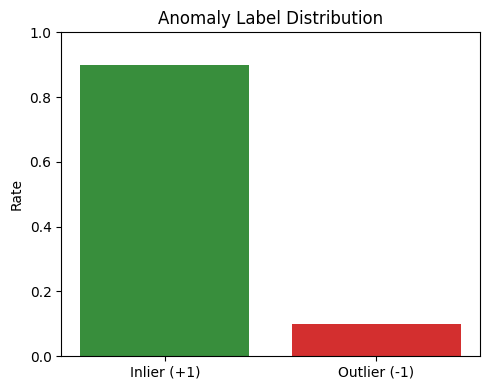

decision_score mean=0.104278, std=0.063525, min=-0.167246, max=0.174294


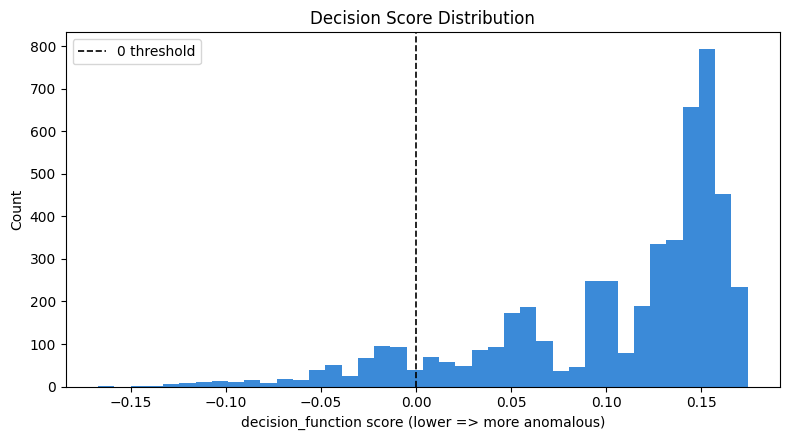

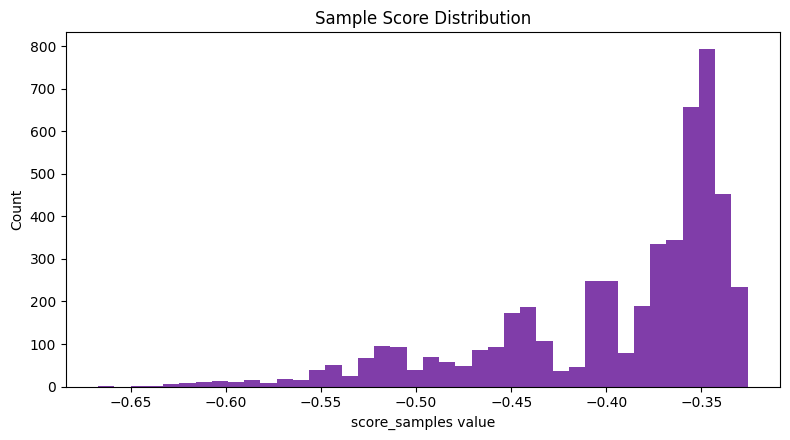

In [9]:
# Diagnostics + diagrams for anomaly score behavior
if 'INFER_MODEL' not in globals():
    print('Run setup cell first.')
else:
    import matplotlib.pyplot as plt

    split_dir = BASE_DIR / 'splits' / 'TON_IoT'
    x_test_proc_path = split_dir / 'X_test_proc.npy'
    if x_test_proc_path.exists():
        X_eval = np.load(x_test_proc_path)
    elif X_BG_DF is not None and INFER_PREPROCESSOR is not None:
        X_eval = np.asarray(INFER_PREPROCESSOR.transform(X_BG_DF))
    else:
        X_eval = None

    if X_eval is None:
        print('No evaluation matrix found for diagnostics.')
    else:
        n = min(5000, X_eval.shape[0])
        X_sub = X_eval[:n]
        preds = INFER_MODEL.predict(X_sub)
        outlier_rate = float((preds == -1).mean())
        inlier_rate = 1.0 - outlier_rate

        print(f'Samples evaluated: {n}')
        print(f'Outlier rate: {outlier_rate:.4f}')

        # Diagram 1: Inlier vs Outlier rate
        plt.figure(figsize=(5, 4))
        plt.bar(['Inlier (+1)', 'Outlier (-1)'], [inlier_rate, outlier_rate], color=['#388e3c', '#d32f2f'])
        plt.ylim(0, 1)
        plt.title('Anomaly Label Distribution')
        plt.ylabel('Rate')
        plt.tight_layout()
        plt.show()

        # Diagram 2: Decision score distribution (when available)
        if hasattr(INFER_MODEL, 'decision_function'):
            d = np.ravel(INFER_MODEL.decision_function(X_sub))
            print(f'decision_score mean={float(d.mean()):.6f}, std={float(d.std()):.6f}, min={float(d.min()):.6f}, max={float(d.max()):.6f}')

            plt.figure(figsize=(8, 4.5))
            plt.hist(d, bins=40, color='#1976d2', alpha=0.85)
            plt.axvline(0.0, color='black', linestyle='--', linewidth=1.2, label='0 threshold')
            plt.title('Decision Score Distribution')
            plt.xlabel('decision_function score (lower => more anomalous)')
            plt.ylabel('Count')
            plt.legend()
            plt.tight_layout()
            plt.show()

        # Diagram 3: score_samples distribution (when available)
        if hasattr(INFER_MODEL, 'score_samples'):
            s = np.ravel(INFER_MODEL.score_samples(X_sub))
            plt.figure(figsize=(8, 4.5))
            plt.hist(s, bins=40, color='#6a1b9a', alpha=0.85)
            plt.title('Sample Score Distribution')
            plt.xlabel('score_samples value')
            plt.ylabel('Count')
            plt.tight_layout()
            plt.show()